# 02_Feature_engineering
## Отбор признаков

##### Импорт модулей

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

##### Загрузка датасета

In [100]:
df = pd.read_csv("../data/raw/smartphone_addiction.csv")

### Проверка на пропуски в данных

In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   str    
 1   user_id                  7500 non-null   str    
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   str    
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   str    
 13  academic_work_impact     7500 non-null   str    
 14  addiction_level          6681 non-n

##### Отсюда видно, что в столбце 14 около тысячи пропусков.

#### Заполняем пропуски в поле уровня зависимости

In [102]:
df['addiction_level'] = df['addiction_level'].fillna('Not Addicted')

#### Отбросим айдишники - они бесполезны

In [103]:
df = df.drop(["user_id", "transaction_id"], axis=1)

#### One-hot encoding `gender` и `academic_work_impact`.

In [104]:
df = pd.get_dummies(df, columns=['gender'], prefix='is', drop_first=True)
df = pd.get_dummies(df, columns=['academic_work_impact'], prefix='academic_work_impact', drop_first=True)

#### Сравнение средних для `Not addicted` и `Mild` addiction levels.

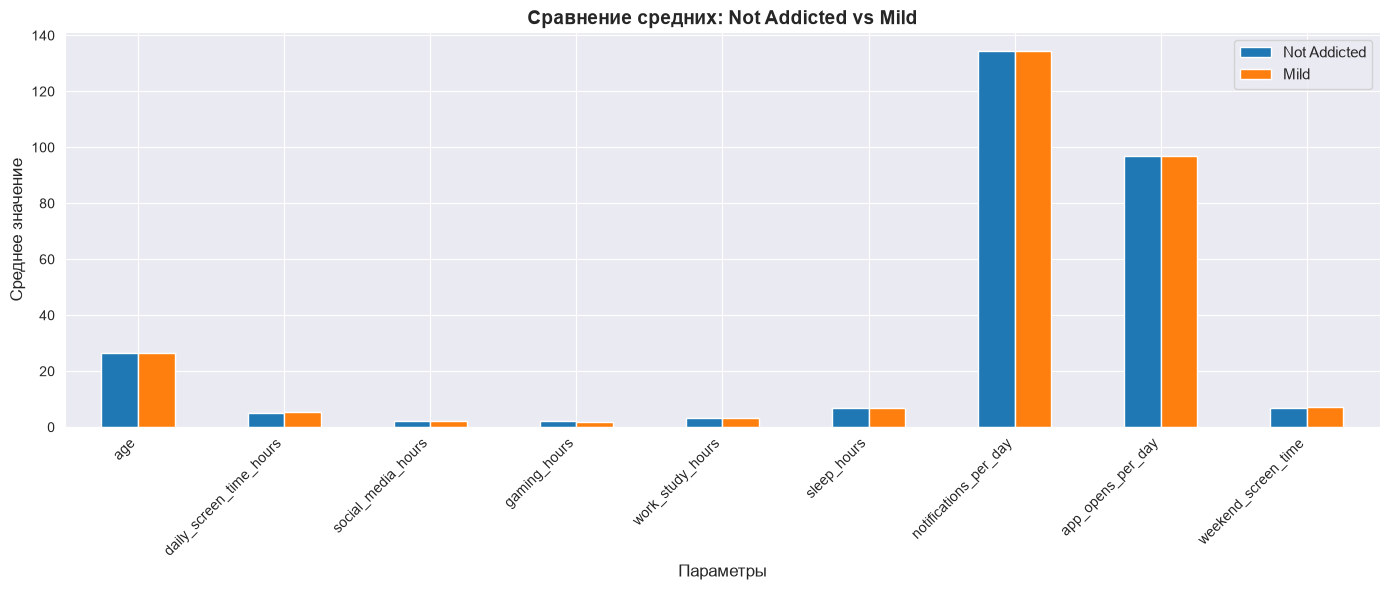

In [105]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col not in ['transaction_id', 'user_id', 'addicted_label']]

not_addicted = df[df['addicted_label'] == 0][numeric_cols].mean()
mild = df[df['addiction_level'] == 'Mild'][numeric_cols].mean()

comparison_df = pd.DataFrame({
    'Not Addicted': not_addicted,
    'Mild': mild
})

comparison_df['Difference'] = comparison_df['Mild'] - comparison_df['Not Addicted']
comparison_df['Percent Change'] = (comparison_df['Difference'] / comparison_df['Not Addicted']) * 100


comparison_df[['Not Addicted', 'Mild']].plot(kind='bar', figsize=(14, 6))
plt.title('Сравнение средних: Not Addicted vs Mild', fontsize=14, fontweight='bold')
plt.xlabel('Параметры', fontsize=12)
plt.ylabel('Среднее значение', fontsize=12)
plt.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Сравнение средних для `Moderate` и `Severe` addiction levels.

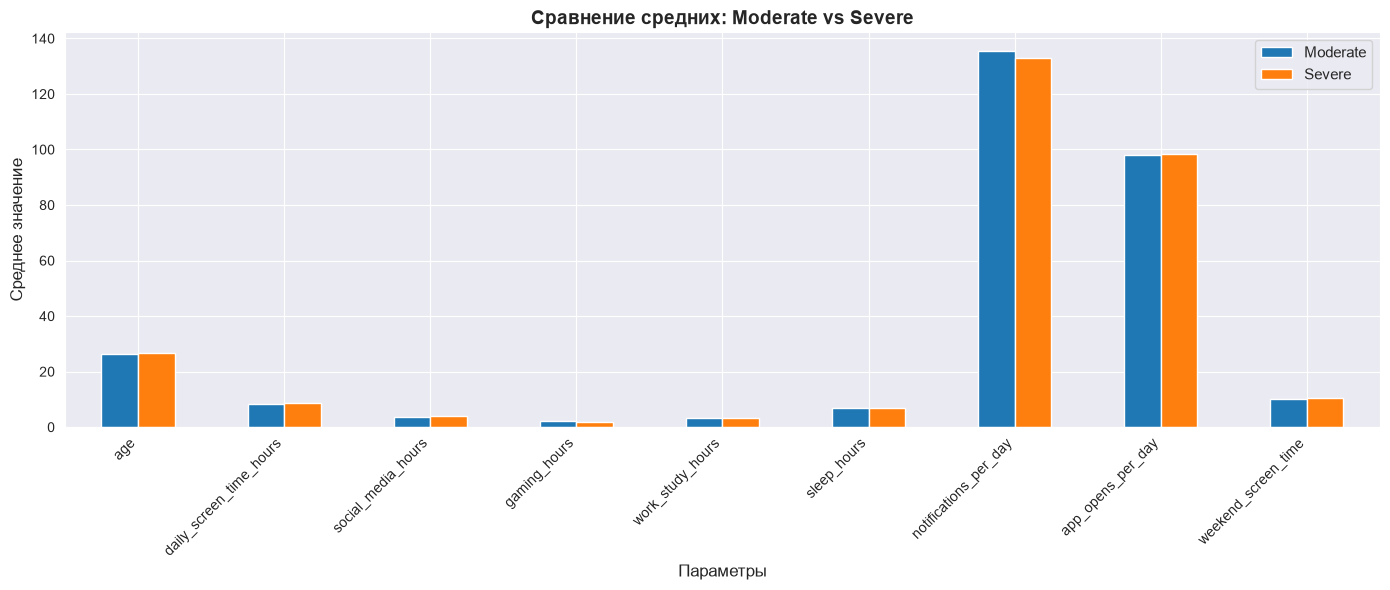

In [106]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col not in ['transaction_id', 'user_id', 'addicted_label']]

moderate = df[df['addiction_level'] == "Moderate"][numeric_cols].mean()
severe = df[df['addiction_level'] == 'Severe'][numeric_cols].mean()

comparison_df = pd.DataFrame({
    'Moderate': moderate,
    'Severe': severe
})

comparison_df['Difference'] = comparison_df['Severe'] - comparison_df['Moderate']
comparison_df['Percent Change'] = (comparison_df['Difference'] / comparison_df['Moderate']) * 100


comparison_df[['Moderate', 'Severe']].plot(kind='bar', figsize=(14, 6))
plt.title('Сравнение средних: Moderate vs Severe', fontsize=14, fontweight='bold')
plt.xlabel('Параметры', fontsize=12)
plt.ylabel('Среднее значение', fontsize=12)
plt.legend(fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### Поскольку средние не отличаются сильно - объединим по две категории.

In [107]:
df.loc[df['addiction_level'] == 'Not Addicted', 'addiction_level'] = 'Mild'
df.loc[df['addiction_level'] == 'Moderate', 'addiction_level'] = 'Severe'

In [108]:
mapping = {'Mild': 0, 'Severe': 1}
df['addiction_level'] = df['addiction_level'].map(mapping)
df['addiction'] = df['addiction_level'].apply(lambda x: 0 if x == 0 else 1)
df = df.drop("addiction_level", axis=1)

mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['stress_level'] = df['stress_level'].map(mapping)

In [109]:
df = df.drop("addicted_label", axis=1)

### Пробуем создать новые фичи

In [110]:
# total weekly screen time
df['total_weekly_screen_hours'] = (df['daily_screen_time_hours'] * 5 + df['weekend_screen_time'] * 2) / 7

# app_opens_per_hour
df['app_opens_per_hour'] = df['app_opens_per_day'] / df['total_weekly_screen_hours']

# avg_session_time
df['avg_session_time'] = df['total_weekly_screen_hours'] * 60 / df['app_opens_per_day']

# sleep_deficit
df['sleep_deficit'] = (7 - df['sleep_hours']).clip(lower=0)

### Проверим на коллинеарность признаки

In [111]:
correlation_matrix = df.corr()

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            high_corr_pairs.append({
                'feature1': correlation_matrix.columns[i],
                'feature2': correlation_matrix.columns[j],
                'correlation': corr_value
            })

high_corr_pairs.sort(key=lambda x: abs(x['correlation']), reverse=True)

if high_corr_pairs:
    for pair in high_corr_pairs:
        print(f"{pair['feature1']:35} <-> {pair['feature2']:35} {pair['correlation']:+.3f}")
else:
    print("Нет пар с корреляцией > 0.7")

daily_screen_time_hours             <-> total_weekly_screen_hours           +0.997
weekend_screen_time                 <-> total_weekly_screen_hours           +0.982
daily_screen_time_hours             <-> weekend_screen_time                 +0.964
sleep_hours                         <-> sleep_deficit                       -0.921
app_opens_per_day                   <-> app_opens_per_hour                  +0.751
app_opens_per_day                   <-> avg_session_time                    -0.723


### Отбор значимых признаков с RandomForest

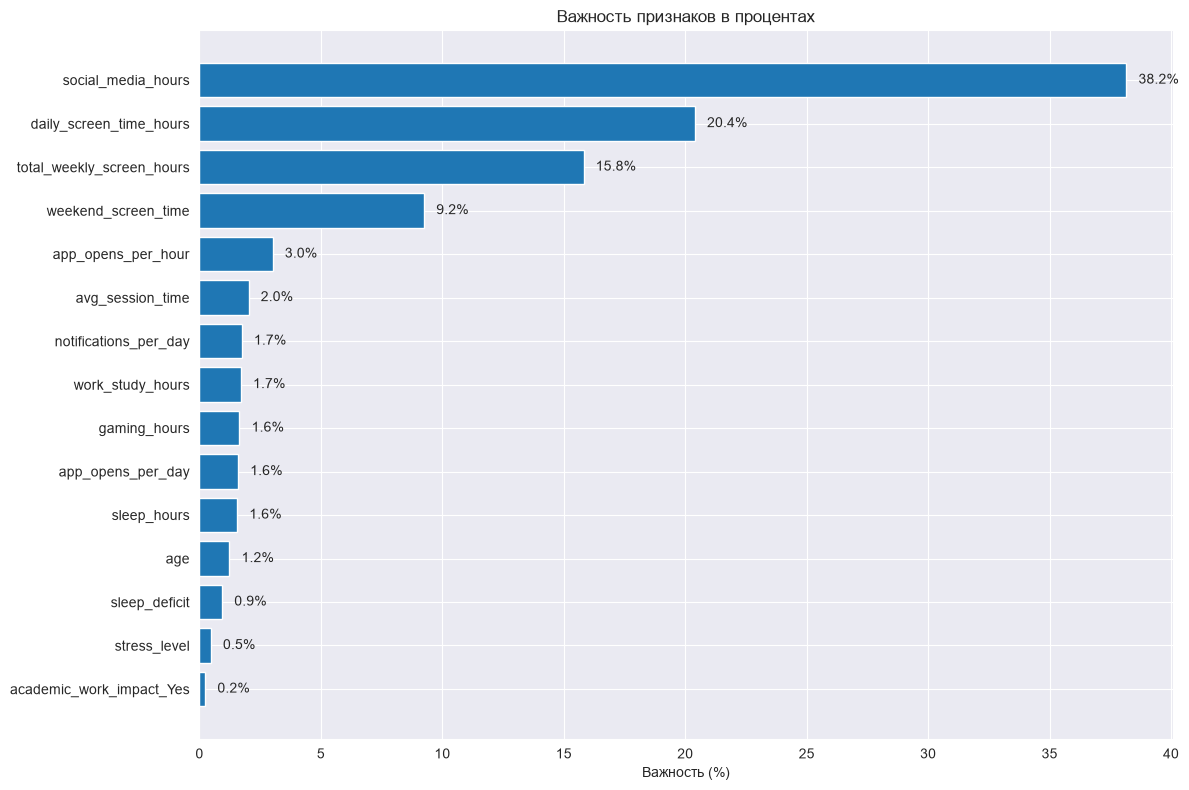

In [112]:
X = df.drop('addiction', axis=1, errors='ignore')
y = df['addiction']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_ * 100
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
top_features = importance.head(15)

plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Важность (%)')
plt.title('Важность признаков в процентах')

for i, v in enumerate(top_features['importance']):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Выберем самые значимые фичи, удалим те новые, которые не дали прироста.

In [113]:
features = ["social_media_hours", "daily_screen_time_hours", "weekend_screen_time", "addiction"]
df = df[features]

#### Сохраним обработанный датасет с 3 фичами.

In [114]:
df.to_csv("../data/processed/smartphone_addiction_proc.csv", index=False)

In [115]:
df.head()

,social_media_hours,daily_screen_time_hours,weekend_screen_time,addiction
0,2.01,3.23,3.95,0
1,3.81,5.09,6.71,0
2,1.36,6.06,8.68,0
3,5.85,7.83,9.77,1
4,5.92,9.96,12.55,1
